In [the first post](../sensitivity-is-not-ppv/index.ipynb), the pre-test probability played the part of a **prior**: what you believed before the test result came back. This post looks at a subtler question about priors. Not *where* a belief is centred, but *how firmly* it's held.

A beta prior has two jobs. Its **mean** says where you expect the truth to be. Its **strength**, α + β, says how much evidence it takes to change your mind. The mean gets all the attention, but the strength often matters more, and it is far easier to get wrong.

This post makes that concrete in three steps:

1. A small change in the spread you *believe* makes a large change in the prior's strength.
2. With thousands of baseball players, the data pin the strength down so tightly that guessing is unnecessary. With a few dozen, they barely constrain it, and getting it wrong breaks the credible intervals.
3. A second, much smaller dataset (rat tumour experiments) shows the problem in real data: a plausible range of prior strengths gives noticeably different answers for the same experiment.

It grew out of working through David Robinson's *Introduction to Empirical Bayes*, which uses baseball batting averages throughout. It's more technical than the first post; if you're here for the clinical side, Sections 5 and 6 stand on their own. The code is Python with NumPy, SciPy, pandas and matplotlib; click **Show the code** to see it.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize, special

rng = np.random.default_rng(2017)
pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (7, 4)

# Chart colours that match the blog's dark (Superhero) theme
# PANEL is a lighter navy at 55% opacity, so the page background shows through slightly
PANEL, LEGEND = "#2b4c6f8c", "#254464"
INK, MUTED, GRID = "#ebebeb", "#a9b3bd", "#3d5a78"
PALETTE = ["#df6919", "#5bc0de", "#5cb85c", "#ffc107", "#d9534f", "#4c9be8"]
plt.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": "none", "savefig.facecolor": PANEL,
    "text.color": INK, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": GRID, "grid.color": GRID,
    "legend.facecolor": LEGEND, "legend.edgecolor": GRID, "legend.labelcolor": INK,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "boxplot.boxprops.color": INK, "boxplot.whiskerprops.color": INK, "boxplot.capprops.color": INK,
    "boxplot.medianprops.color": PALETTE[0], "boxplot.flierprops.markeredgecolor": MUTED,
})

## 1. Spread is strength

Write the prior as Beta(α, β), with mean μ = α/(α+β) and strength ν = α + β. Its variance is

$$\sigma^2 = \frac{\mu(1-\mu)}{\nu + 1}, \qquad\text{so}\qquad \nu = \frac{\mu(1-\mu)}{\sigma^2} - 1, \quad \alpha = \mu\nu, \quad \beta = (1-\mu)\nu.$$

The variance fixes the total, ν, and the mean splits it into α "pseudo-hits" and β "pseudo-misses". The catch is the $1/\sigma^2$: the strength depends on the *inverse square* of the spread. Halve the spread and the prior becomes four times as strong.

Take a batting average of μ = 0.27 and a few spreads that all sound reasonable for "most hitters land between about .21 and .35":

In [2]:
def strength_from_spread(mu, sigma):
    """Prior strength nu = alpha + beta implied by a mean and a standard deviation."""
    return mu * (1 - mu) / sigma**2 - 1

mu = 0.27
rows = []
for sigma in [0.02, 0.0256, 0.035, 0.05]:
    nu = strength_from_spread(mu, sigma)
    rows.append({"sigma": sigma, "nu = alpha + beta": nu,
                 "alpha": mu * nu, "beta": (1 - mu) * nu})
spread_table = pd.DataFrame(rows)
spread_table

,sigma,nu = alpha + beta,alpha,beta
0,0.020,491.750,132.772,358.977
1,0.026,299.751,80.933,218.818
2,0.035,159.898,43.172,116.726
3,0.050,77.840,21.017,56.823


Spreads of 0.02 and 0.035 differ by less than 0.02 of batting average, yet one prior is worth about 490 at-bats and the other about 160: a factor of three. All four curves below are centred on .270; they differ only in how firmly they hold that belief.

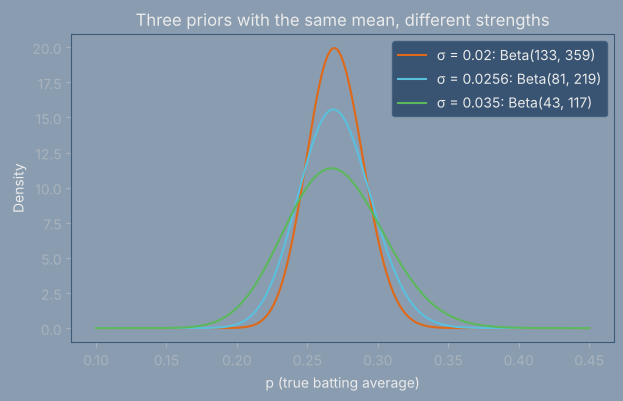

In [3]:
x = np.linspace(0.1, 0.45, 600)
for sigma in [0.02, 0.0256, 0.035]:
    nu = strength_from_spread(mu, sigma)
    plt.plot(x, stats.beta(mu * nu, (1 - mu) * nu).pdf(x),
             label=f"σ = {sigma}: Beta({mu * nu:.0f}, {(1 - mu) * nu:.0f})")
plt.xlabel("p (true batting average)")
plt.ylabel("Density")
plt.title("Three priors with the same mean, different strengths")
plt.legend()
plt.show()

## 2. What strength does to an estimate

After $H$ hits in $AB$ at-bats, the posterior mean is

$$\hat p = \frac{H + \mu\nu}{AB + \nu} = w \cdot \frac{H}{AB} + (1 - w)\cdot\mu, \qquad w = \frac{AB}{AB + \nu}.$$

So the estimate is a weighted average of the player's own record and the prior mean, and ν is the number of at-bats at which the two get equal weight. Every player is pulled toward μ; ν decides how hard.

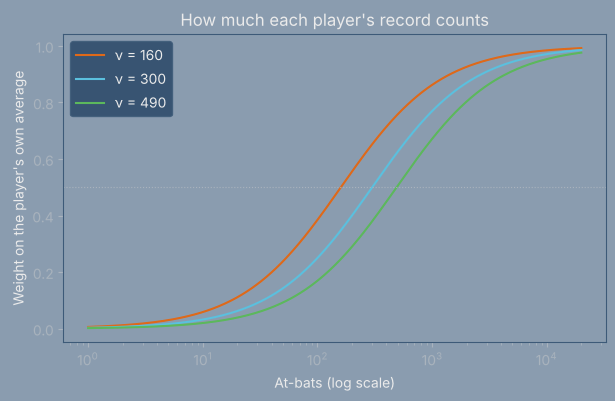

In [4]:
AB = np.geomspace(1, 20000, 400)
for nu in [160, 300, 490]:
    plt.plot(AB, AB / (AB + nu), label=f"ν = {nu}")
plt.axhline(0.5, color=MUTED, lw=0.8, ls=":")
plt.xscale("log")
plt.xlabel("At-bats (log scale)")
plt.ylabel("Weight on the player's own average")
plt.title("How much each player's record counts")
plt.legend()
plt.show()

In [5]:
records = [(4, 10), (100, 300), (3000, 10000)]
rows = []
for H, n in records:
    row = {"record": f"{H}/{n}", "raw": H / n}
    for nu in [160, 300, 490]:
        row[f"ν = {nu}"] = (H + mu * nu) / (n + nu)
    rows.append(row)
pd.DataFrame(rows)

,record,raw,ν = 160,ν = 300,ν = 490
0,4/10,0.400,0.278,0.274,0.273
1,100/300,0.333,0.311,0.302,0.294
2,3000/10000,0.300,0.300,0.299,0.299


For the 100-for-300 hitter the three priors disagree by about .017, roughly the gap between a good hitter and an average one. For a 4-for-10 call-up the prior is almost everything, whichever strength we choose. For a 10,000 at-bat veteran the prior hardly matters at all. Prior strength is a question about the players we know *least* about, which is exactly where we need help.

So which strength is right? Guessing a spread from "mostly between .21 and .35" left us anywhere from 160 to 490. Empirical Bayes replaces the guess with an estimate.

## 3. Let the data decide: 4,600 baseball careers

We use the [Lahman Baseball Database](https://sabr.org/lahman-database/): career hits and at-bats for every major-league player, with pitchers removed because they form a separate, much weaker-hitting group. Following Robinson, we fit the prior on the players with more than 500 at-bats. The model is beta-binomial: each player's true average comes from Beta(μν, (1−μ)ν), and his hits are binomial given that average. Maximum likelihood picks μ and ν.

In [6]:
from pathlib import Path

LAHMAN_DIR = Path("data/lahman")   # unzip the CSV version from https://sabr.org/lahman-database/ here

def load(name):
    path = next(LAHMAN_DIR.rglob(f"{name}.csv"))
    return pd.read_csv(path, encoding="utf-8-sig", low_memory=False)

batting, pitching, people = load("Batting"), load("Pitching"), load("People")
batting = batting[(batting["AB"] > 0) & ~batting["playerID"].isin(pitching["playerID"])]
career = (batting.groupby("playerID")[["H", "AB"]].sum().reset_index()
          .merge(people[["playerID", "nameFirst", "nameLast"]], on="playerID"))
fit_set = career[career["AB"] > 500]           # the players the prior is fitted on
print(f"{len(career):,} players; {len(fit_set):,} with more than 500 at-bats")

11,725 players; 4,672 with more than 500 at-bats


In [7]:
def bb_loglik(mu, nu, H, AB):
    """Beta-binomial log-likelihood with the prior written as mean mu and strength nu."""
    return stats.betabinom.logpmf(H, AB, mu * nu, (1 - mu) * nu).sum()

def fit_mu_nu(H, AB, nu_max=1e5):
    """Maximum-likelihood mu and nu (optimized on the logit and log scales)."""
    def nll(params):
        return -bb_loglik(special.expit(params[0]), np.exp(params[1]), H, AB)
    start = [special.logit(H.sum() / AB.sum()), np.log(100)]
    res = optimize.minimize(nll, start, method="Nelder-Mead",
                            options={"xatol": 1e-6, "fatol": 1e-6, "maxiter": 4000})
    return special.expit(res.x[0]), min(np.exp(res.x[1]), nu_max)

H, AB = fit_set["H"].to_numpy(), fit_set["AB"].to_numpy()
mu_hat, nu_hat = fit_mu_nu(H, AB)
print(f"mu = {mu_hat:.4f}, nu = {nu_hat:.0f}  ->  "
      f"Beta({mu_hat * nu_hat:.1f}, {(1 - mu_hat) * nu_hat:.1f}); "
      f"implied sigma = {np.sqrt(mu_hat * (1 - mu_hat) / (nu_hat + 1)):.4f}")

mu = 0.2599, nu = 367  ->  Beta(95.3, 271.5); implied sigma = 0.0229


The data choose a prior worth roughly 370 at-bats, centred near .260 (a little below .270 because these are career averages over 150 years of baseball). The implied spread is about 0.023, inside the range we guessed but nowhere near pinned down by guessing.

How sure are the data about that ν? A **profile likelihood** answers it: fix ν at each value on a grid, find the best μ for it, and record how well that pair fits. Values of ν whose fit is within 1.92 log-likelihood units of the best form an approximate 95% interval.

Values of nu the data support (95%): 353 to 383


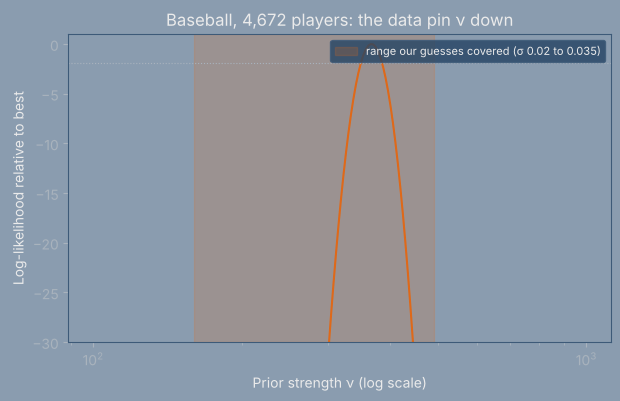

In [8]:
def profile_loglik(nu, H, AB):
    """Best log-likelihood achievable with strength fixed at nu (mu re-optimized)."""
    res = optimize.minimize_scalar(lambda m: -bb_loglik(m, nu, H, AB),
                                   bounds=(1e-4, 1 - 1e-4), method="bounded")
    return -res.fun

def profile_curve(H, AB, grid):
    ll = np.array([profile_loglik(nu, H, AB) for nu in grid])
    rel = ll - ll.max()
    inside = grid[rel > -1.92]          # approximate 95% likelihood interval
    return rel, (inside.min(), inside.max())

grid = np.geomspace(100, 1000, 200)
rel, (lo, hi) = profile_curve(H, AB, grid)
print(f"Values of nu the data support (95%): {lo:.0f} to {hi:.0f}")

plt.plot(grid, rel)
plt.axhline(-1.92, color=MUTED, ls=":", lw=0.8)
plt.axvspan(160, 490, color=PALETTE[0], alpha=0.2, label="range our guesses covered (σ 0.02 to 0.035)")
plt.xscale("log")
plt.ylim(-30, 1)
plt.xlabel("Prior strength ν (log scale)")
plt.ylabel("Log-likelihood relative to best")
plt.title(f"Baseball, {len(H):,} players: the data pin ν down")
plt.legend(loc="upper right", fontsize=8)
plt.show()

The curve is a narrow spike. Thousands of players, many with long careers, leave little doubt about how spread out true batting averages are: ν is somewhere between about 350 and 385, and everything we guessed in Section 1 except the middle value is firmly ruled out. This is why empirical Bayes works so well on this dataset: the prior's strength is not an assumption, it is a measurement.

## 4. When the data can't decide: 30 players

What happens with fewer observations? Robinson's book asks this of the whole method; here we look at the strength directly. Treat the fitted prior as the truth, simulate small leagues by drawing real career lengths at random, give each player a true average from the prior and hits from the binomial, and look at the profile likelihood again.

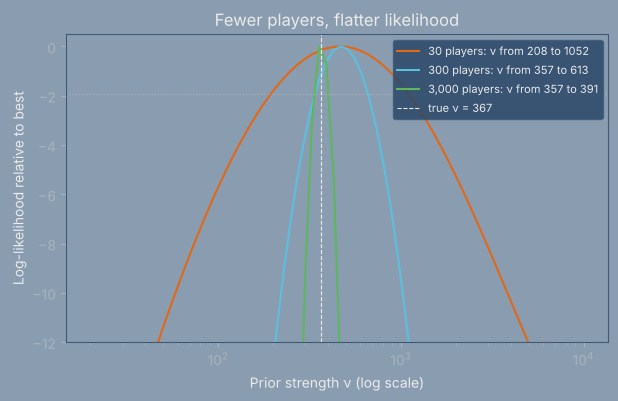

In [9]:
alpha0, beta0 = mu_hat * nu_hat, (1 - mu_hat) * nu_hat   # the "true" prior for the simulations
AB_pool = career["AB"].to_numpy()                          # real careers, short and long

def simulate(n_players):
    ab = rng.choice(AB_pool, n_players, replace=True)
    p = rng.beta(alpha0, beta0, n_players)
    return rng.binomial(ab, p), ab, p

grid = np.geomspace(20, 10000, 70)
for n_players in [30, 300, 3000]:
    h, ab, _ = simulate(n_players)
    rel, (lo, hi) = profile_curve(h, ab, grid)
    plt.plot(grid, rel, label=f"{n_players:,} players: ν from {lo:.0f} to {hi:.0f}")
plt.axvline(nu_hat, color=INK, ls="--", lw=0.8, label=f"true ν = {nu_hat:.0f}")
plt.axhline(-1.92, color=MUTED, ls=":", lw=0.8)
plt.xscale("log")
plt.ylim(-12, 0.5)
plt.xlabel("Prior strength ν (log scale)")
plt.ylabel("Log-likelihood relative to best")
plt.title("Fewer players, flatter likelihood")
plt.legend(fontsize=8)
plt.show()

With 3,000 players the curve is still sharp. With 300 it has widened. With 30 it is nearly flat across a factor of five: the data are consistent with a prior worth 200 at-bats or 1,000. Thirty players simply don't reveal how spread out the truth is, because each player's own record is noisy and there are too few of them to separate that noise from genuine differences between players.

One flat curve could be bad luck, so repeat the whole experiment 100 times at each size, record the estimated ν, and check how often each player's 95% credible interval contains his true average.

In [10]:
sizes, reps = [30, 100, 300, 1000], 100
results = []
start = time.perf_counter()
for n_players in sizes:
    for rep in range(reps):
        h, ab, p = simulate(n_players)
        m, nu = fit_mu_nu(h, ab)
        post_a, post_b = m * nu + h, (1 - m) * nu + ab - h
        low, high = stats.beta.ppf(0.025, post_a, post_b), stats.beta.ppf(0.975, post_a, post_b)
        results.append({"players": n_players, "nu_hat": nu,
                        "coverage": np.mean((low <= p) & (p <= high))})
    print(f"{n_players:>5} players: {reps} replications done "
          f"({time.perf_counter() - start:.1f} s so far)")
results = pd.DataFrame(results)
summary = results.groupby("players").agg(
    nu_median=("nu_hat", "median"),
    nu_10th=("nu_hat", lambda s: s.quantile(0.1)),
    nu_90th=("nu_hat", lambda s: s.quantile(0.9)),
    coverage_mean=("coverage", "mean"),
    coverage_worst=("coverage", "min"))
print(f"True nu = {nu_hat:.0f}. Done in {time.perf_counter() - start:.1f} s.")
summary

   30 players: 100 replications done (2.0 s so far)
  100 players: 100 replications done (2.9 s so far)
  300 players: 100 replications done (4.1 s so far)
 1000 players: 100 replications done (6.5 s so far)
True nu = 367. Done in 6.5 s.


,nu_median,nu_10th,nu_90th,coverage_mean,coverage_worst
players,,,,,
30,434.693,261.509,1016.236,0.881,0.100
100,382.213,297.316,542.204,0.942,0.820
300,379.811,315.654,444.767,0.945,0.890
1000,359.784,321.129,401.598,0.950,0.924


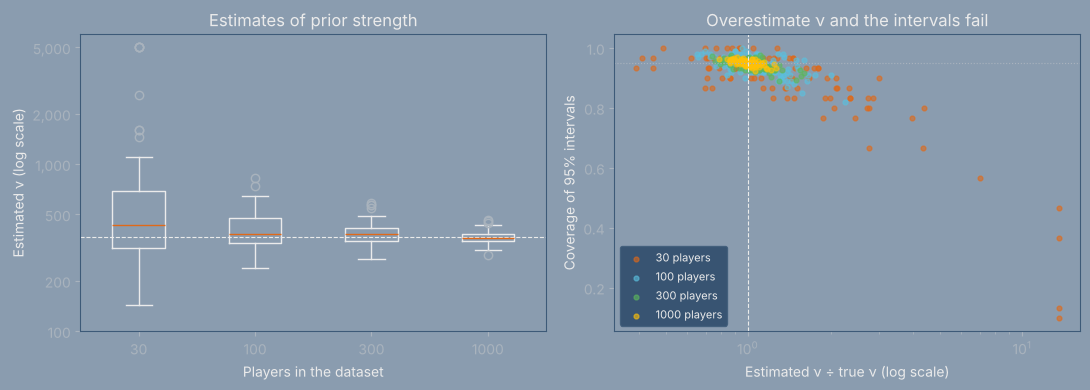

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.boxplot([results.loc[results.players == s, "nu_hat"].clip(upper=5000) for s in sizes],
            tick_labels=[str(s) for s in sizes])
ax1.axhline(nu_hat, color=INK, ls="--", lw=0.8)
ax1.set_yscale("log")
ax1.set_yticks([100, 200, 500, 1000, 2000, 5000], labels=["100", "200", "500", "1,000", "2,000", "5,000"])
ax1.minorticks_off()
ax1.set_xlabel("Players in the dataset")
ax1.set_ylabel("Estimated ν (log scale)")
ax1.set_title("Estimates of prior strength")

for s in sizes:
    sub = results[results.players == s]
    ax2.scatter(sub["nu_hat"].clip(upper=5000) / nu_hat, sub["coverage"], s=12, alpha=0.6, label=f"{s} players")
ax2.axvline(1, color=INK, ls="--", lw=0.8)
ax2.axhline(0.95, color=MUTED, ls=":", lw=0.8)
ax2.set_xscale("log")
ax2.set_xlabel("Estimated ν ÷ true ν (log scale)")
ax2.set_ylabel("Coverage of 95% intervals")
ax2.set_title("Overestimate ν and the intervals fail")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

Two patterns stand out.

- **The estimate of ν scatters widely with few players.** With 30 players it ranges over roughly a factor of four between the 10th and 90th percentiles, and in a few replications no overdispersion is visible at all, so the estimate runs off toward infinity (shown capped at 5,000).
- **Overestimating ν is what breaks the intervals.** In the right-hand plot every replication that lands well to the right of the dashed line, a prior estimated as stronger than it really is, has coverage below 95%, sometimes far below. An over-strong prior over-shrinks every player toward the mean and makes every interval too narrow. Underestimating ν costs much less: the intervals come out a little too wide, and coverage stays near or above 95%.

That asymmetry is the practical lesson: the dangerous mistake is a prior that is *too confident*, and small datasets are exactly where it happens.

## 5. A second example: rat tumour experiments

Baseball is the friendly case. A classic dataset from Gelman et al.'s *Bayesian Data Analysis* is less forgiving. A drug study observed tumours in 4 of 14 rats in its control group. Seventy earlier control groups, of about 20 rats each, provide historical context. How surprising is 4 of 14?

This is the same structure as batting averages (tumours out of rats instead of hits out of at-bats), but with 70 groups instead of 4,600, and groups of 20 instead of careers of thousands.

In [12]:
# Tumours (y) out of rats (n) in 71 experiments (Gelman et al., Bayesian Data Analysis, 3rd ed.,
# Section 5.3). The first 70 are historical controls; the last (4 of 14) is the current experiment.
y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
              2, 2, 2, 1, 5, 2, 5, 3, 2, 7, 7, 3, 3, 2, 9, 10, 4, 4, 4, 4, 4, 4, 4, 10, 4, 4, 4, 5,
              11, 12, 5, 5, 6, 5, 6, 6, 6, 6, 16, 15, 15, 9, 4])
n = np.array([20, 20, 20, 20, 20, 20, 20, 19, 19, 19, 19, 18, 18, 17, 20, 20, 20, 20, 19, 19, 18, 18,
              25, 24, 23, 20, 20, 20, 20, 20, 20, 10, 49, 19, 46, 27, 17, 49, 47, 20, 20, 13, 48, 50,
              20, 20, 20, 20, 20, 20, 20, 48, 19, 19, 19, 22, 46, 49, 20, 20, 23, 19, 22, 20, 20, 20,
              52, 46, 47, 24, 14])
y_hist, n_hist = y[:-1], n[:-1]
print(f"{len(y_hist)} historical experiments, {n_hist.sum()} rats, "
      f"pooled tumour rate {y_hist.sum() / n_hist.sum():.3f}; current experiment {y[-1]}/{n[-1]}")

70 historical experiments, 1725 rats, pooled tumour rate 0.152; current experiment 4/14


mu = 0.141, nu = 16.4  ->  Beta(2.30, 14.08)
Values of nu the data support (95%): 9.3 to 32.7


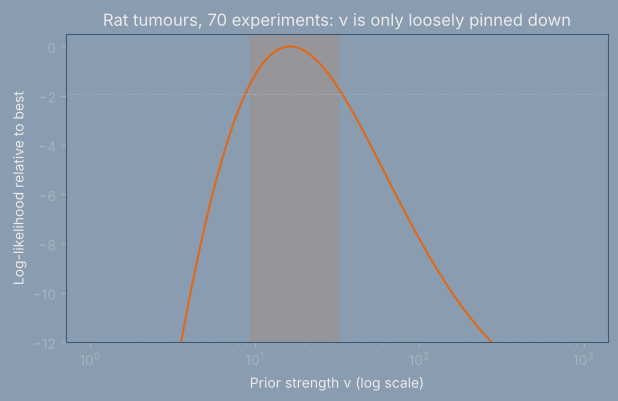

In [13]:
mu_rat, nu_rat = fit_mu_nu(y_hist, n_hist)
grid_rat = np.geomspace(1, 1000, 100)
rel_rat, (lo_rat, hi_rat) = profile_curve(y_hist, n_hist, grid_rat)
print(f"mu = {mu_rat:.3f}, nu = {nu_rat:.1f}  ->  Beta({mu_rat * nu_rat:.2f}, {(1 - mu_rat) * nu_rat:.2f})")
print(f"Values of nu the data support (95%): {lo_rat:.1f} to {hi_rat:.1f}")

plt.plot(grid_rat, rel_rat)
plt.axhline(-1.92, color=MUTED, ls=":", lw=0.8)
plt.axvspan(lo_rat, hi_rat, alpha=0.15)
plt.xscale("log")
plt.ylim(-12, 0.5)
plt.xlabel("Prior strength ν (log scale)")
plt.ylabel("Log-likelihood relative to best")
plt.title("Rat tumours, 70 experiments: ν is only loosely pinned down")
plt.show()

The best estimate is a weak prior, Beta(2.3, 14.1): worth about 16 rats, centred on a 14% tumour rate. But the profile likelihood is wide. Anything from about 9 to 33 fits nearly as well, a factor of three or more, the same uncertainty our guesses had in Section 1. Seventy small experiments can't settle it.

Does that matter for the question we actually care about, the current experiment?

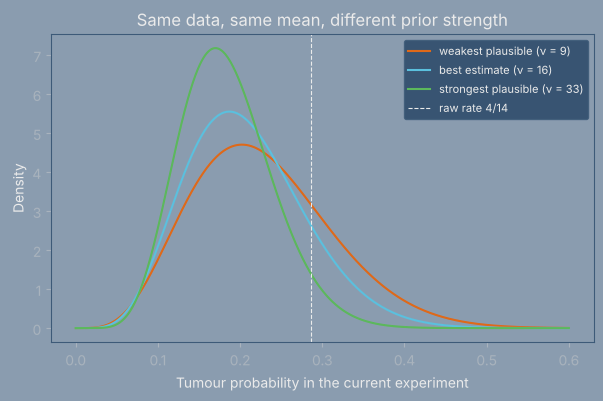

,prior,nu,posterior mean,95% low,95% high
0,weakest plausible,9.326,0.228,0.086,0.414
1,best estimate,16.385,0.207,0.086,0.366
2,strongest plausible,32.745,0.184,0.088,0.306


In [14]:
x = np.linspace(0, 0.6, 600)
rows = []
for label, nu in [("weakest plausible", lo_rat), ("best estimate", nu_rat), ("strongest plausible", hi_rat)]:
    a, b = mu_rat * nu + y[-1], (1 - mu_rat) * nu + n[-1] - y[-1]
    low, high = stats.beta.ppf([0.025, 0.975], a, b)
    rows.append({"prior": label, "nu": nu, "posterior mean": a / (a + b), "95% low": low, "95% high": high})
    plt.plot(x, stats.beta(a, b).pdf(x), label=f"{label} (ν = {nu:.0f})")
plt.axvline(y[-1] / n[-1], color=INK, ls="--", lw=0.8, label="raw rate 4/14")
plt.xlabel("Tumour probability in the current experiment")
plt.ylabel("Density")
plt.title("Same data, same mean, different prior strength")
plt.legend(fontsize=8)
plt.show()
pd.DataFrame(rows)

It does. The raw rate is 4/14 = 0.29. Within the range the data support, the posterior mean moves from about 0.23 to 0.18, and the upper end of the 95% interval from about 0.41 to 0.31. A reader asking "is this group's rate unusually high?" would get a noticeably different impression depending on a choice the data cannot make for us. Plugging in the single best estimate (as empirical Bayes does) hides that uncertainty entirely.

## 6. What to do about it

- **Look at the strength, not just the mean.** Convert any prior you write down into ν = α + β and ask: "is my belief really worth this many observations?"
- **Let the data estimate it when there are many groups.** With thousands of groups, as in baseball, the estimate is precise and empirical Bayes is hard to beat.
- **Check how precise the estimate is.** A profile likelihood for ν takes a few lines of code. A narrow curve means plug-in empirical Bayes is safe; a wide one means it isn't.
- **When the curve is wide, report a range.** Show results for the weakest and strongest plausible priors, as in the rat example, so readers can see how much depends on the choice.
- **Or stop plugging in.** A full Bayesian model puts a prior on μ and ν and averages over every plausible strength instead of committing to one. With 30 players or 70 rat experiments, that is what keeps credible intervals honest. A future post will fit exactly that model in PyMC.

The general point: a prior's strength is a claim about how much you already know. Small changes in a spread that "seems reasonable" can double or halve that claim, and only enough data, or an honest account of uncertainty, can check it.

## References

- *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapters 2–3 (the beta prior and its fit) and 13 (simulating replications, varying sample size).
- Gelman, Carlin, Stern, Dunson, Vehtari & Rubin, *Bayesian Data Analysis* (3rd ed.), Section 5.3: the rat tumour experiments.
- Tarone (1982), "The use of historical control information in testing for a trend in proportions", *Biometrics* 38(1): the source of the rat tumour data.
- Lahman Baseball Database (CC BY-SA 3.0): https://sabr.org/lahman-database/